# **PROJECT 1: TIME SERIES & CATEGORY CHARTS**
This project analyses opioid overdose deaths across all 50 US states using real public health data.
The dataset includes state population, total overdose deaths, and state abbreviations,
allowing for both absolute and per-capita comparisons.

In [12]:
import pandas as pd

df_opioids = pd.read_csv('/opioids.csv')
df_overdoses = pd.read_csv('/overdoses.csv')
df_prescriber = pd.read_csv('/prescriber-info.csv')

print("----------OPIOIDS----------")
print(df_opioids.head())

print("\n----------OVERDOSES----------")
print(df_overdoses.head())

print("\n----------PRESCRIBER INFO----------")
print(df_prescriber.head())

----------OPIOIDS----------
                        Drug Name                    Generic Name
0                         ABSTRAL                FENTANYL CITRATE
1           ACETAMINOPHEN-CODEINE      ACETAMINOPHEN WITH CODEINE
2                           ACTIQ                FENTANYL CITRATE
3             ASCOMP WITH CODEINE  CODEINE/BUTALBITAL/ASA/CAFFEIN
4  ASPIRIN-CAFFEINE-DIHYDROCODEIN  DIHYDROCODEINE/ASPIRIN/CAFFEIN

----------OVERDOSES----------
        State  Population Deaths Abbrev
0     Alabama   4,833,722    723     AL
1      Alaska     735,132    124     AK
2     Arizona   6,626,624  1,211     AZ
3    Arkansas   2,959,373    356     AR
4  California  38,332,521  4,521     CA

----------PRESCRIBER INFO----------
          NPI Gender State Credentials            Specialty  ABILIFY  \
0  1710982582      M    TX         DDS              Dentist        0   
1  1245278100      F    AL          MD      General Surgery        0   
2  1427182161      F    NY        M.D.     General P

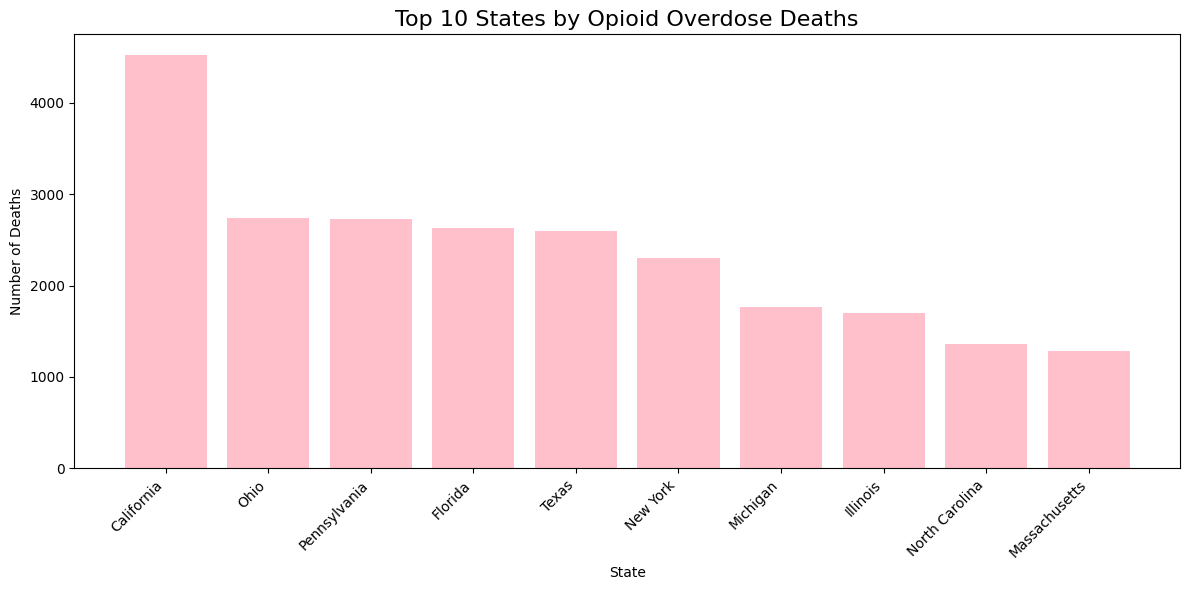

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/overdoses.csv')

df['Population'] = df['Population'].astype(str).str.replace(',', '').astype(float)
df['Deaths'] = df['Deaths'].astype(str).str.replace(',', '').astype(float)

df['Deaths_Per_100k'] = (df['Deaths'] / df['Population']) * 100000


top10 = df.nlargest(10, 'Deaths')

plt.figure(figsize=(12, 6))
plt.bar(top10['State'], top10['Deaths'], color='pink')
plt.title('Top 10 States by Opioid Overdose Deaths', fontsize=16)
plt.xlabel('State')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart1_bar.png')
plt.show()


### **Chart 1: Top 10 States by Total Opioid Overdose Deaths (Bar Chart)**
A bar chart was chosen to compare total overdose deaths across states clearly and directly.
California ranks highest in total deaths, followed by Ohio, Pennsylvania and Florida.
However, total deaths alone can be misleading as larger states naturally have more deaths
due to bigger populations.

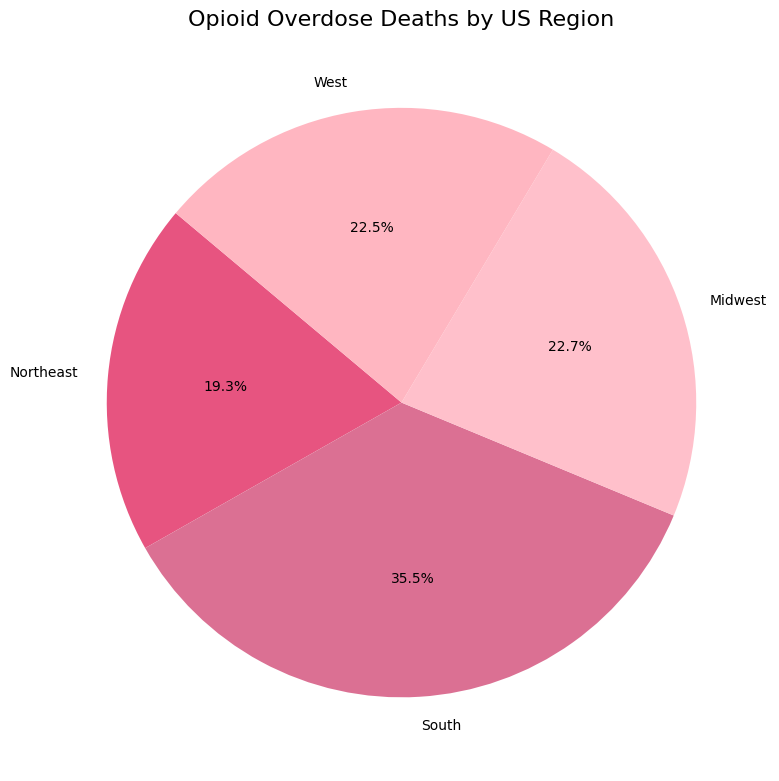

In [26]:
regions = {
    'Northeast': ['CT','ME','MA','NH','RI','VT','NJ','NY','PA'],
    'South': ['AL','AR','DE','FL','GA','KY','LA','MD','MS','NC','OK','SC','TN','TX','VA','WV'],
    'Midwest': ['IL','IN','IA','KS','MI','MN','MO','NE','ND','OH','SD','WI'],
    'West': ['AK','AZ','CA','CO','HI','ID','MT','NV','NM','OR','UT','WA','WY']
}

region_deaths = {}
for region, abbrevs in regions.items():
    region_deaths[region] = df[df['Abbrev'].isin(abbrevs)]['Deaths'].sum()

plt.figure(figsize=(8, 8))
plt.pie(region_deaths.values(), labels=region_deaths.keys(),
        autopct='%1.1f%%', startangle=140,
        colors=['#e75480','#db7093','#ffc0cb','#ffb6c1'])
plt.title('Opioid Overdose Deaths by US Region', fontsize=16)
plt.tight_layout()
plt.savefig('chart2_pie.png')
plt.show()

### **Chart 2: Opioid Overdose Deaths by US Region (Pie Chart)**

A pie chart was used to show each region's share of the national death toll.
The South accounts for 35.5% of all opioid overdose deaths — the largest share of any region.
This reflects how Purdue Pharma aggressively marketed OxyContin in rural southern states,
flooding communities with prescription opioids throughout the late 1990s and 2000s.

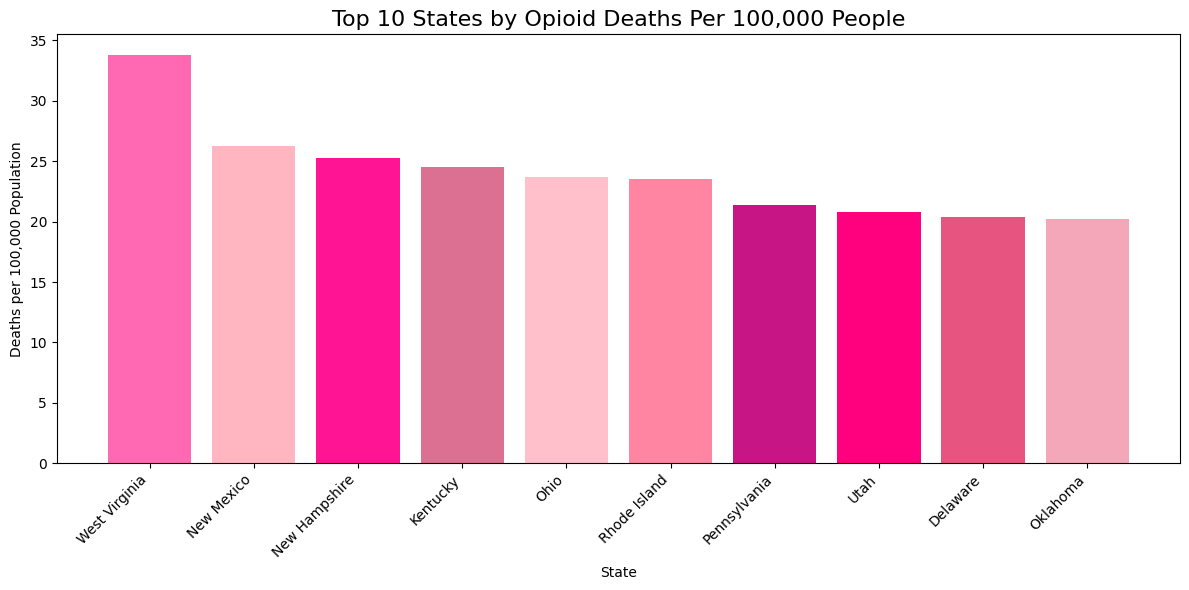

In [28]:
top10_capita = df.nlargest(10, 'Deaths_Per_100k')

plt.figure(figsize=(12, 6))
bars = plt.bar(top10_capita['State'], top10_capita['Deaths_Per_100k'],
        color=['#ff69b4','#ffb6c1','#ff1493','#db7093','#ffc0cb',
               '#ff85a2','#c71585','#ff007f','#e75480','#f4a7b9'])
plt.title('Top 10 States by Opioid Deaths Per 100,000 People', fontsize=16)
plt.xlabel('State')
plt.ylabel('Deaths per 100,000 Population')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart3_capita.png')
plt.show()

### **Chart 3: Top 10 States by Deaths Per 100,000 People (Bar Chart)**
Adjusting for population reveals a completely different picture.
West Virginia ranks number 1 with nearly 34 deaths per 100,000 people —
far ahead of any other state. Kentucky, Ohio and New Hampshire also feature heavily.
These are smaller, rural states that were disproportionately targeted by opioid manufacturers.
This per-capita view is the most honest representation of where the crisis hit hardest.



###  Key Insight
The difference between Chart 1 and Chart 3 demonstrates why per-capita analysis matters
in data science. California appears worst in raw numbers but West Virginia tells the
true story of the opioid crisis — a small state devastated by predatory pharmaceutical marketing.